<a href="https://colab.research.google.com/github/IsabelaReali/ciencias_de_dados_arvore/blob/main/decision_tree.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
!pip install dtreeviz

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 102.3/102.3 kB 5.9 MB/s eta 0:00:00


In [4]:
from sklearn.datasets import load_iris
from sklearn import tree
import graphviz
from sklearn.model_selection import cross_val_score
from sklearn.inspection import permutation_importance
import dtreeviz.trees
import pandas as pd
from sklearn import datasets
from matplotlib import pyplot as plt
import numpy as np

In [5]:
dataset = pd.read_excel("/content/base_clientes_5000.xlsx")

In [6]:
dataset.head()

,id_cliente,idade,data_cadastro,data_ultima_compra,dias_desde_ultima_compra,total_compras,valor_total_compras,ticket_medio,envios_crm,aberturas_crm,cliques_crm,conversoes_crm,taxa_abertura,taxa_conversao,recomprou_90_dias
0,1,53,10/05/2025,23/01/2026,234,4,170.88,42.72,30,14,4,2,0.4667,0.0667,1
1,2,43,31/12/2025,19/07/2026,57,4,301.72,75.43,57,29,9,3,0.5088,0.0526,1
2,3,27,10/11/2025,01/09/2026,13,3,131.04,43.68,64,39,13,6,0.6094,0.0938,1
3,4,48,02/05/2023,06/12/2023,1013,6,262.56,43.76,39,7,2,1,0.1795,0.0256,0
4,5,50,11/04/2024,10/07/2025,431,6,347.46,57.91,51,16,7,4,0.3137,0.0784,1


In [7]:
dataset.shape

(5000, 15)

In [8]:
X = dataset.iloc[:,[0,1,2]]
print(X)

      id_cliente  idade data_cadastro
0              1     53    10/05/2025
1              2     43    31/12/2025
2              3     27    10/11/2025
3              4     48    02/05/2023
4              5     50    11/04/2024
...          ...    ...           ...
4995        4996     59    13/01/2023
4996        4997     19    07/11/2025
4997        4998     19    24/11/2024
4998        4999     44    30/08/2025
4999        5000     31    23/04/2023

[5000 rows x 3 columns]


In [12]:
y = dataset["recomprou_90_dias"]
print(y)

0       1
1       1
2       1
3       0
4       1
       ..
4995    0
4996    1
4997    1
4998    1
4999    0
Name: recomprou_90_dias, Length: 5000, dtype: int64


In [10]:
clf = tree.DecisionTreeClassifier(criterion = 'entropy')

In [13]:
X = dataset[
    [
        "idade",
        "dias_desde_ultima_compra",
        "total_compras",
        "valor_total_compras",
        "ticket_medio",
        "envios_crm",
        "aberturas_crm",
        "cliques_crm",
        "conversoes_crm",
        "taxa_abertura",
        "taxa_conversao"
    ]
]

y = dataset["recomprou_90_dias"]

In [ ]:
clf = clf.fit(one_hot_data, y)

In [15]:
clf.fit(X, y)

DecisionTreeClassifier(criterion='entropy')

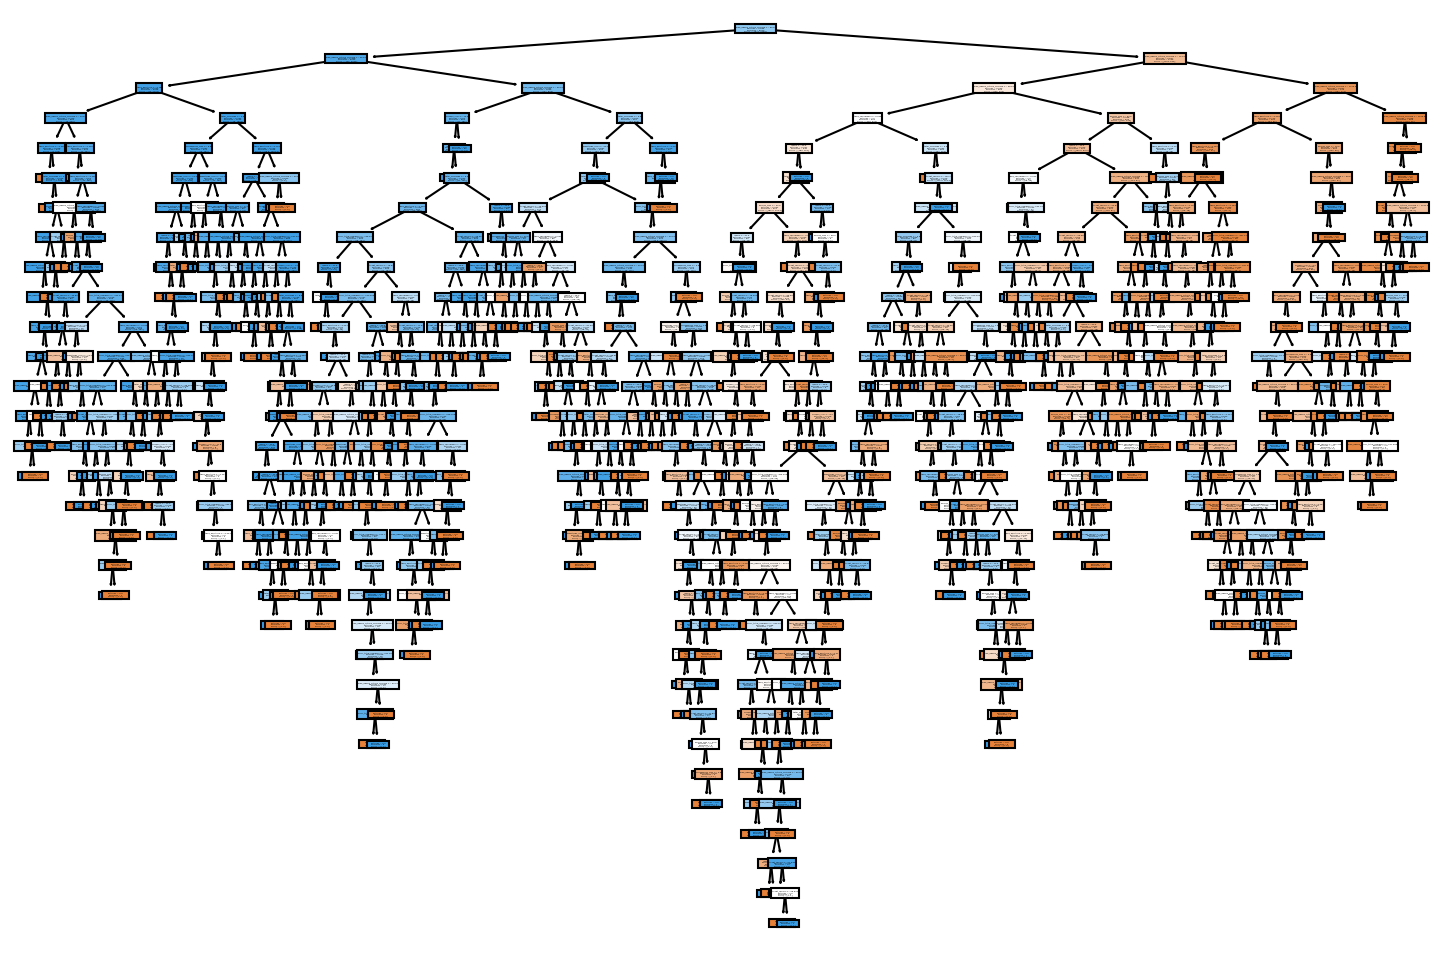

In [16]:
fn = [
    "idade",
    "dias_desde_ultima_compra",
    "total_compras",
    "valor_total_compras",
    "ticket_medio",
    "envios_crm",
    "aberturas_crm",
    "cliques_crm",
    "conversoes_crm",
    "taxa_abertura",
    "taxa_conversao"
]

cn = ["Não recomprou", "Recomprou"]

fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(12, 8), dpi=150)

tree.plot_tree(
    clf,
    feature_names=fn,
    class_names=cn,
    filled=True
)

fig.savefig("arvore_recompra.png")
plt.show()

In [17]:
iris = load_iris()
X, y = iris.data, iris.target

In [18]:
X = dataset[
    [
        "idade",
        "dias_desde_ultima_compra",
        "total_compras",
        "valor_total_compras",
        "ticket_medio",
        "envios_crm",
        "aberturas_crm",
        "cliques_crm",
        "conversoes_crm",
        "taxa_abertura",
        "taxa_conversao"
    ]
]

y = dataset["recomprou_90_dias"]

print(X)

      idade  dias_desde_ultima_compra  total_compras  valor_total_compras  \
0        53                       234              4               170.88   
1        43                        57              4               301.72   
2        27                        13              3               131.04   
3        48                      1013              6               262.56   
4        50                       431              6               347.46   
...     ...                       ...            ...                  ...   
4995     59                      1264              3               271.11   
4996     19                        13              5               483.85   
4997     19                       430              2                36.62   
4998     44                        13              8               583.12   
4999     31                      1001              3               205.74   

      ticket_medio  envios_crm  aberturas_crm  cliques_crm  conversoes_crm 

In [19]:
clf = tree.DecisionTreeClassifier(criterion = 'entropy')

In [20]:
clf = clf.fit(X, y)

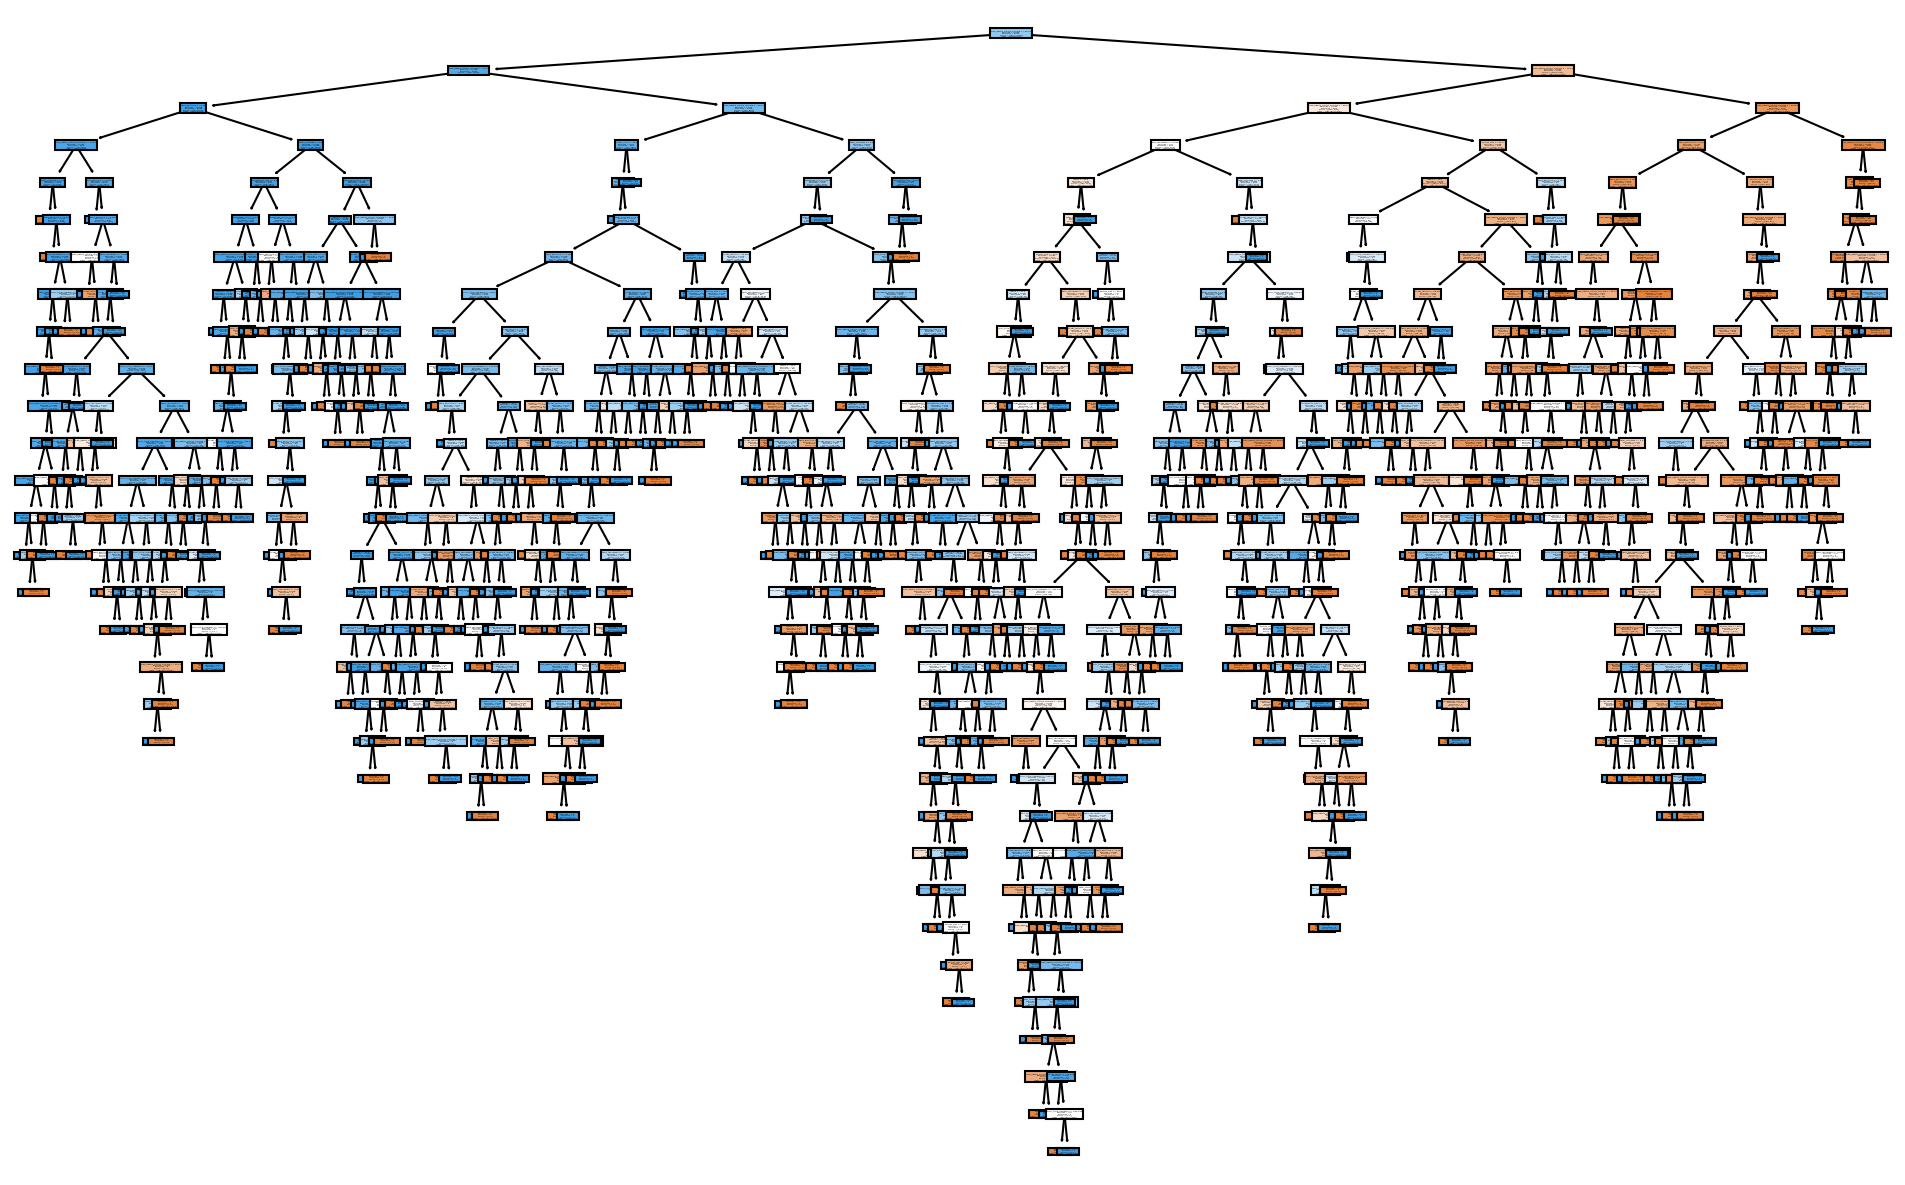

In [21]:
fn = [
    "idade",
    "dias_desde_ultima_compra",
    "total_compras",
    "valor_total_compras",
    "ticket_medio",
    "envios_crm",
    "aberturas_crm",
    "cliques_crm",
    "conversoes_crm",
    "taxa_abertura",
    "taxa_conversao"
]

cn = ["Não recomprou", "Recomprou"]

fig, axes = plt.subplots(
    nrows=1,
    ncols=1,
    figsize=(16, 10),
    dpi=150
)

tree.plot_tree(
    clf,
    feature_names=fn,
    class_names=cn,
    filled=True
)

fig.savefig("arvore_recompra.png")
plt.show()

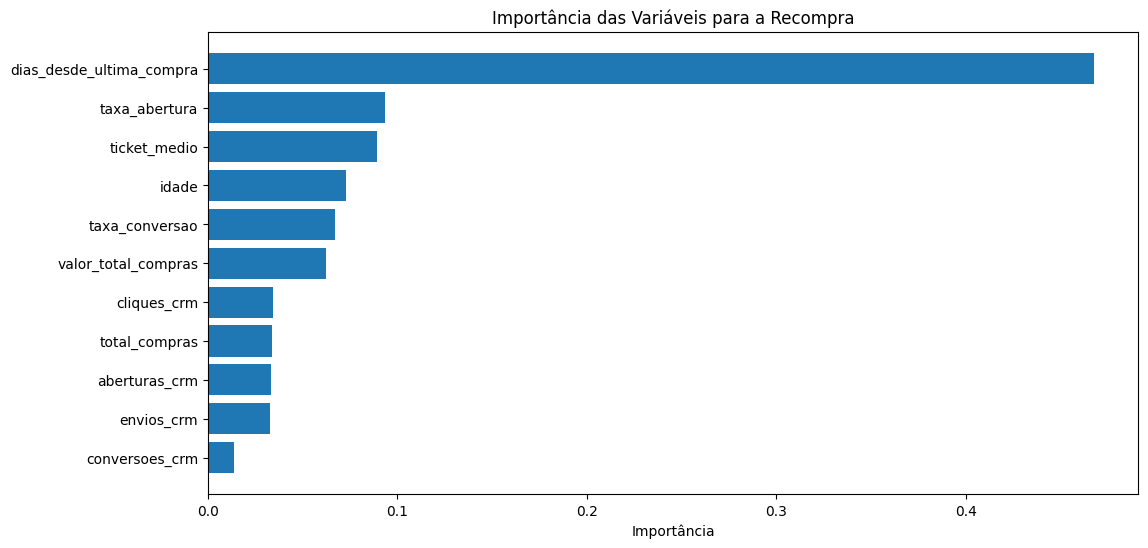

In [22]:
feature_importance = clf.feature_importances_
sorted_idx = np.argsort(feature_importance)

fn = [
    "idade",
    "dias_desde_ultima_compra",
    "total_compras",
    "valor_total_compras",
    "ticket_medio",
    "envios_crm",
    "aberturas_crm",
    "cliques_crm",
    "conversoes_crm",
    "taxa_abertura",
    "taxa_conversao"
]

fig = plt.figure(figsize=(12, 6))

plt.barh(
    range(len(sorted_idx)),
    feature_importance[sorted_idx],
    align="center"
)

plt.yticks(
    range(len(sorted_idx)),
    np.array(fn)[sorted_idx]
)

plt.xlabel("Importância")
plt.title("Importância das Variáveis para a Recompra")

plt.show()

Referências

https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html

https://www.rasgoml.com/feature-engineering-tutorials/how-to-generate-feature-importance-plots-from-scikit-learn

https://medium.com/chinmaygaikwad/feature-importance-and-visualization-of-tree-models-d491e8198b0a

